# Task 2 - Yelp Polarity Sentiment Classification

Member: shreya. Three models trained from scratch, no pretrained embeddings or language models.
Settings come from `../config.yaml`.


## Colab setup

Does nothing when run locally. On Colab, Drive should look like this:

```
MyDrive/DATA266_Lab1/task2_sentiment/data/train.csv
MyDrive/DATA266_Lab1/task2_sentiment/data/test.csv
MyDrive/DATA266_Lab1/task2_sentiment/shreya/...
```

`DATA266_Lab1` acts as the repo root, so logs and manifests are written to
`MyDrive/DATA266_Lab1/reproducibility/`.

Generate the CSVs on your own machine with `python task2_sentiment/fetch_data.py`, then upload them.
Open this notebook from Drive so saved output goes back into the repo.


In [1]:
import os, sys
from pathlib import Path

if "google.colab" in sys.modules:
    from google.colab import drive
    drive.mount("/content/drive")

    root = Path("/content/drive/MyDrive/DATA266_Lab1")
    if not (root / "task2_sentiment" / "data" / "train.csv").exists():
        raise FileNotFoundError(f"upload train.csv and test.csv to {root/'task2_sentiment'/'data'}")

    os.environ["LAB1_ROOT"] = str(root)
    os.chdir(root / "task2_sentiment" / "shreya_akotiya" / "src")
    print("root:", root)
else:
    print("running locally")


Mounted at /content/drive
root: /content/drive/MyDrive/DATA266_Lab1


In [2]:
import json, time, random, string, logging, platform, hashlib, resource, subprocess
from collections import Counter
from datetime import datetime

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             confusion_matrix, roc_auc_score, average_precision_score,
                             matthews_corrcoef, brier_score_loss, roc_curve,
                             precision_recall_curve)
from scipy.stats import binomtest, chi2


def find_root():
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "task2_sentiment").is_dir():
            return p
    raise RuntimeError("run from inside the repo, or set LAB1_ROOT")

ROOT = Path(os.environ["LAB1_ROOT"]).resolve() if os.environ.get("LAB1_ROOT") else find_root()
MEMBER = "shreya_akotiya"
TASK = ROOT / "task2_sentiment"
SHARED = TASK / "data"
MDIR = TASK / MEMBER
OUT, PROC, CKPT = MDIR / "outputs", MDIR / "data_processed", MDIR / "checkpoints"
PLOTS = OUT / "plots"
LOGS = ROOT / "reproducibility" / "raw_logs" / MEMBER / "task2_sentiment"
MANIFESTS = ROOT / "reproducibility" / "manifests" / MEMBER
for d in (OUT, PROC, CKPT, PLOTS, LOGS, MANIFESTS):
    d.mkdir(parents=True, exist_ok=True)

CFG = yaml.safe_load(open(Path(os.environ.get("LAB1_CONFIG") or (MDIR / "config.yaml"))))
RUN_TAG = f"task2_{MEMBER}_{CFG['run']['run_name']}_{datetime.now():%Y%m%d_%H%M%S}"

log_path = LOGS / f"{RUN_TAG}.log"
logger = logging.getLogger("task2"); logger.handlers.clear()
logger.setLevel(logging.INFO); logger.propagate = False
for h in (logging.FileHandler(log_path), logging.StreamHandler(sys.stdout)):
    h.setFormatter(logging.Formatter("%(asctime)s | %(message)s", "%H:%M:%S"))
    logger.addHandler(h)
log = logger.info

SEED = CFG["run"]["seed"]
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

pref = CFG["run"]["device"]
DEVICE = torch.device(pref if pref != "auto" else
                      ("cuda" if torch.cuda.is_available() else
                       "mps" if torch.backends.mps.is_available() else "cpu"))

# spec 2.2.5: record the exact CPU/GPU
if DEVICE.type == "cuda":
    HW = torch.cuda.get_device_name(0)
elif DEVICE.type == "mps":
    HW = subprocess.run(["sysctl", "-n", "machdep.cpu.brand_string"],
                        capture_output=True, text=True).stdout.strip() + " (MPS)"
else:
    HW = platform.processor() or platform.machine()

log(f"{RUN_TAG} | {DEVICE} | {HW} | torch {torch.__version__}")


22:20:11 | task2_shreya_main_20260921_222011 | cuda | Tesla T4 | torch 2.11.0+cu128


## 2.1.1 Review length, class distribution, class balance


22:20:20 | loaded 560,000 train / 38,000 test
22:20:20 | train classes {0: np.int64(280000), 1: np.int64(280000)} balance 1.0000
22:20:20 | test classes {0: np.int64(19000), 1: np.int64(19000)} balance 1.0000
22:20:30 | words per review: mean 133 median 97 p90 282 p99 608 max 1052
22:20:30 | max_len 200 vs raw words: 80.3% of reviews whole (preprocessing removes about half the tokens, so the real figure is higher)
22:20:30 | median words by class {0: 112.0, 1: 84.0}


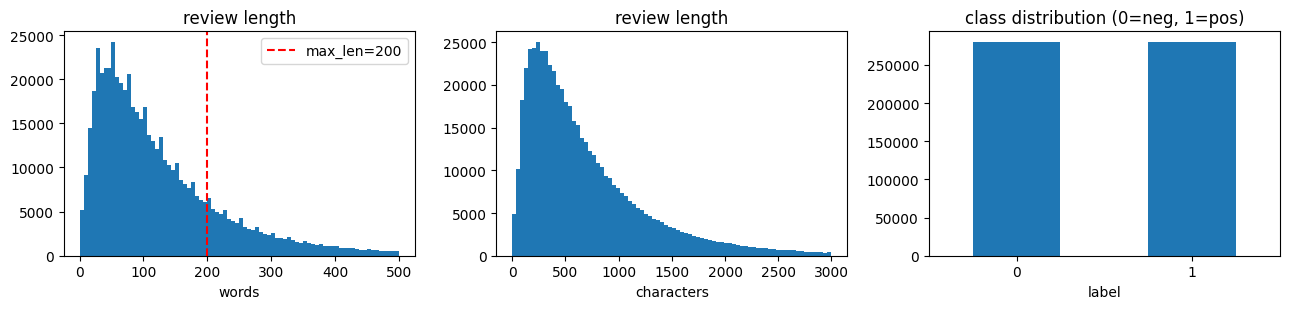

In [3]:
train_path, test_path = SHARED / CFG["data"]["train_csv"], SHARED / CFG["data"]["test_csv"]
if not train_path.exists():
    raise FileNotFoundError(f"missing {train_path}\nrun: python {MDIR/'src'/'fetch_data.py'}")

train_full = pd.read_csv(train_path)
test_full = pd.read_csv(test_path)
log(f"loaded {len(train_full):,} train / {len(test_full):,} test")

for name, df in (("train", train_full), ("test", test_full)):
    c = df.label.value_counts().sort_index()
    log(f"{name} classes {dict(c)} balance {c.min()/c.max():.4f}")

words = train_full.text.fillna("").str.split().str.len()
chars = train_full.text.fillna("").str.len()
log(f"words per review: mean {words.mean():.0f} median {words.median():.0f} "
    f"p90 {words.quantile(.90):.0f} p99 {words.quantile(.99):.0f} max {words.max()}")

MAX_LEN = CFG["preprocess"]["max_len"]
log(f"max_len {MAX_LEN} vs raw words: {(words <= MAX_LEN).mean()*100:.1f}% of reviews whole "
    f"(preprocessing removes about half the tokens, so the real figure is higher)")
log(f"median words by class {train_full.assign(w=words).groupby('label').w.median().to_dict()}")

fig, ax = plt.subplots(1, 3, figsize=(13, 3.2))
ax[0].hist(words, bins=80, range=(0, 500))
ax[0].axvline(MAX_LEN, color="r", ls="--", label=f"max_len={MAX_LEN}")
ax[0].set_xlabel("words"); ax[0].set_title("review length"); ax[0].legend()
ax[1].hist(chars, bins=80, range=(0, 3000))
ax[1].set_xlabel("characters"); ax[1].set_title("review length")
train_full.label.value_counts().sort_index().plot.bar(ax=ax[2], rot=0)
ax[2].set_title("class distribution (0=neg, 1=pos)")
fig.tight_layout(); fig.savefig(PLOTS / "eda.png", dpi=120); plt.show()


## 2.1.2 Missing and malformed entries


In [4]:
def clean(df, name):
    n0 = len(df)
    df = df.dropna(subset=["text", "label"])
    df = df[df.text.astype(str).str.strip() != ""]
    df = df[df.label.isin([0, 1])]
    df = df.drop_duplicates(subset=["text"]).reset_index(drop=True)
    log(f"{name} {n0:,} -> {len(df):,} (dropped {n0-len(df):,})")
    return df

train_full = clean(train_full, "train")
test_full = clean(test_full, "test")

# Validation comes out of train, so the official test set is only used at the end.
n_val = CFG["data"]["n_val"]
n_train = CFG["data"]["n_train"] or (len(train_full) - n_val)
shuffled = train_full.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
val_df = shuffled.iloc[:n_val].reset_index(drop=True)
train_df = shuffled.iloc[n_val:n_val + n_train].reset_index(drop=True)
test_df = (test_full if not CFG["data"]["n_test"] else
           test_full.sample(CFG["data"]["n_test"], random_state=SEED).reset_index(drop=True))

log(f"train {len(train_df):,} | val {len(val_df):,} | test {len(test_df):,}")
log(f"positive rate: train {train_df.label.mean():.4f} val {val_df.label.mean():.4f} "
    f"test {test_df.label.mean():.4f}")


22:20:34 | train 560,000 -> 560,000 (dropped 0)
22:20:34 | test 38,000 -> 38,000 (dropped 0)
22:20:34 | train 540,000 | val 20,000 | test 38,000
22:20:34 | positive rate: train 0.4999 val 0.5032 test 0.5000


## 2.1.3 Text preprocessing

Lowercase, strip punctuation, remove stopwords, light stemming.

Negations are kept out of the stopword list. `not`, `no`, `never` and the `n't` contractions are all
in sklearn's list, but "not good" and "good" are opposite sentiment.


In [5]:
NEGATIONS = {"no", "not", "nor", "never", "none", "nothing", "nobody", "neither",
             "cannot", "cant", "wont", "dont", "didnt", "doesnt", "isnt", "wasnt",
             "arent", "werent", "hasnt", "havent", "hadnt", "shouldnt", "wouldnt",
             "couldnt", "aint", "without", "hardly", "barely", "scarcely"}

P = CFG["preprocess"]
STOPWORDS = set(ENGLISH_STOP_WORDS) - (NEGATIONS if P["keep_negations"] else set())
PUNCT = str.maketrans({c: " " for c in string.punctuation})
log(f"stopwords {len(ENGLISH_STOP_WORDS)} -> {len(STOPWORDS)}")


def stem(w):
    for suf, cut in (("ies", 3), ("sses", 2), ("ing", 3), ("edly", 4), ("ed", 2), ("ly", 2), ("s", 1)):
        if len(w) - cut >= 3 and w.endswith(suf):
            return w[:-cut] + ("y" if suf == "ies" else "")
    return w


def preprocess(text):
    t = str(text)
    if P["lowercase"]:
        t = t.lower()
    t = t.replace("\\n", " ")
    t = t.replace("n't", "nt")          # keep the negation once punctuation is stripped
    if P["strip_punctuation"]:
        t = t.translate(PUNCT)
    out = t.split()
    if P["remove_stopwords"]:
        out = [w for w in out if w not in STOPWORDS]
    if P["stem"]:
        out = [stem(w) for w in out]
    return [w for w in out if w]


demo = "The food was NOT good, and I don't think I'll ever return!!!"
log(f"demo: {preprocess(demo)}")
assert "not" in preprocess(demo) and "dont" in preprocess(demo)

t0 = time.time()
train_tok = [preprocess(t) for t in train_df.text]
val_tok = [preprocess(t) for t in val_df.text]
test_tok = [preprocess(t) for t in test_df.text]
log(f"tokenised {len(train_tok)+len(val_tok)+len(test_tok):,} reviews in {time.time()-t0:.0f}s")
tok_len = np.array([len(t) for t in train_tok])
log(f"mean words {words.mean():.1f} raw -> {tok_len.mean():.1f} processed "
    f"({(1-tok_len.mean()/words.mean())*100:.0f}% removed)")
log(f"processed tokens: median {np.median(tok_len):.0f} p90 {np.percentile(tok_len,90):.0f} "
    f"p95 {np.percentile(tok_len,95):.0f} p99 {np.percentile(tok_len,99):.0f}")
log(f"max_len {MAX_LEN} keeps {(tok_len <= MAX_LEN).mean()*100:.1f}% of reviews whole, "
    f"{np.minimum(tok_len, MAX_LEN).sum()/tok_len.sum()*100:.1f}% of all tokens")
log(f"empty after preprocessing: {(tok_len == 0).sum()}")


22:20:34 | stopwords 318 -> 305
22:20:34 | demo: ['food', 'not', 'good', 'dont', 'think', 'll', 'return']
22:21:22 | tokenised 598,000 reviews in 48s
22:21:22 | mean words 133.0 raw -> 63.5 processed (52% removed)
22:21:22 | processed tokens: median 46 p90 133 p95 176 p99 288
22:21:22 | max_len 200 keeps 96.6% of reviews whole, 96.3% of all tokens
22:21:23 | empty after preprocessing: 35


## 2.1.4 / 2.1.5 Vocabulary, encoding, embeddings learned from scratch


In [6]:
# Vocabulary from the training set only.
counts = Counter(w for doc in train_tok for w in doc)
keep = [w for w, n in counts.most_common(P["max_vocab"]) if n >= P["min_word_freq"]]
itos = ["<pad>", "<unk>"] + keep
stoi = {w: i for i, w in enumerate(itos)}
PAD, UNK, VOCAB = 0, 1, len(itos)

cov = sum(counts[w] for w in keep) / sum(counts.values())
log(f"vocab {VOCAB:,} of {len(counts):,} unique words | token coverage {cov*100:.2f}%")


def encode(docs):
    X = np.zeros((len(docs), MAX_LEN), dtype=np.int32)
    M = np.zeros((len(docs), MAX_LEN), dtype=np.float32)
    for i, doc in enumerate(docs):
        ids = [stoi.get(w, UNK) for w in doc[:MAX_LEN]] or [UNK]
        X[i, :len(ids)] = ids
        M[i, :len(ids)] = 1.0
    return X, M

Xtr, Mtr = encode(train_tok); ytr = train_df.label.values.astype(np.int64)
Xva, Mva = encode(val_tok);   yva = val_df.label.values.astype(np.int64)
Xte, Mte = encode(test_tok);  yte = test_df.label.values.astype(np.int64)

unk_rate = float((Xtr[Mtr > 0] == UNK).mean())
log(f"encoded train {Xtr.shape} val {Xva.shape} test {Xte.shape}")
log(f"<unk> rate {unk_rate*100:.2f}% | mean tokens kept {Mtr.sum(1).mean():.1f} / {MAX_LEN}")

json.dump({"itos": itos, "vocab_size": VOCAB, "max_len": MAX_LEN}, open(PROC / "vocab.json", "w"))

# Embeddings are the nn.Embedding layers below, randomly initialised. Nothing is loaded
# from GloVe, word2vec, fastText or any pretrained model.


22:21:28 | vocab 48,436 of 170,326 unique words | token coverage 99.47%
22:21:38 | encoded train (540000, 200) val (20000, 200) test (38000, 200)
22:21:38 | <unk> rate 0.52% | mean tokens kept 61.1 / 200


## 2.2.1 Models

Embedding dim is the same for all three, so the comparison reflects architecture rather than
capacity.

| model | how it reads a review |
|---|---|
| `baseline_meanpool` | average the word vectors, one linear layer. No word order. |
| `exp_textcnn` | conv widths 3/4/5 then max-pool. Sees short phrases. |
| `exp_bilstm` | BiLSTM, max-pool over time. Carries state across the review. |


In [7]:
class MeanPool(nn.Module):
    def __init__(self, vocab, emb_dim, dropout):
        super().__init__()
        self.emb = nn.Embedding(vocab, emb_dim, padding_idx=PAD)
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(emb_dim, 2)

    def forward(self, x, mask):
        h = self.emb(x) * mask.unsqueeze(-1)
        h = h.sum(1) / mask.sum(1, keepdim=True).clamp(min=1)
        return self.fc(self.drop(h))


class TextCNN(nn.Module):
    def __init__(self, vocab, emb_dim, n_filters, kernel_sizes, dropout):
        super().__init__()
        self.emb = nn.Embedding(vocab, emb_dim, padding_idx=PAD)
        self.convs = nn.ModuleList([nn.Conv1d(emb_dim, n_filters, k) for k in kernel_sizes])
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(n_filters * len(kernel_sizes), 2)

    def forward(self, x, mask):
        h = (self.emb(x) * mask.unsqueeze(-1)).transpose(1, 2)
        h = torch.cat([F.relu(c(h)).max(-1).values for c in self.convs], -1)
        return self.fc(self.drop(h))


class BiLSTM(nn.Module):
    def __init__(self, vocab, emb_dim, hidden, n_layers, dropout):
        super().__init__()
        self.emb = nn.Embedding(vocab, emb_dim, padding_idx=PAD)
        self.lstm = nn.LSTM(emb_dim, hidden, n_layers, batch_first=True, bidirectional=True,
                            dropout=dropout if n_layers > 1 else 0.0)
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden * 2, 2)

    def forward(self, x, mask):
        h, _ = self.lstm(self.emb(x))
        h = h.masked_fill(mask.unsqueeze(-1) == 0, float("-inf"))   # padding never wins the max
        return self.fc(self.drop(h.max(1).values))


def build(name):
    m = CFG["models"][name]
    if m["type"] == "meanpool":
        net = MeanPool(VOCAB, m["emb_dim"], m["dropout"])
    elif m["type"] == "textcnn":
        net = TextCNN(VOCAB, m["emb_dim"], m["n_filters"], m["kernel_sizes"], m["dropout"])
    elif m["type"] == "bilstm":
        net = BiLSTM(VOCAB, m["emb_dim"], m["hidden"], m["n_layers"], m["dropout"])
    else:
        raise ValueError(m["type"])
    nn.init.normal_(net.emb.weight, 0, 0.1)
    with torch.no_grad():
        net.emb.weight[PAD].zero_()
    return net.to(DEVICE)

for name in CFG["models"]:
    log(f"{name:20s} {CFG['models'][name]['type']:9s} "
        f"{sum(p.numel() for p in build(name).parameters()):,} params")


22:21:39 | baseline_meanpool    meanpool  9,687,602 params
22:21:39 | exp_textcnn          textcnn   9,928,102 params
22:21:39 | exp_bilstm           bilstm    10,025,634 params


## 2.2 Training


In [8]:
T = CFG["train"]
BATCH = T["batch_size"]


def batches(X, M, y, size, shuffle=False):
    idx = np.random.permutation(len(X)) if shuffle else np.arange(len(X))
    for i in range(0, len(idx), size):
        j = idx[i:i + size]
        # blocking .to() on purpose: non_blocking on MPS can hand over a freed buffer
        yield (torch.from_numpy(X[j]).long().to(DEVICE),
               torch.from_numpy(M[j]).to(DEVICE),
               torch.from_numpy(y[j]).to(DEVICE))


def peak_mem_mb():
    if DEVICE.type == "cuda":
        return torch.cuda.max_memory_allocated() / 1e6
    if DEVICE.type == "mps":
        return torch.mps.driver_allocated_memory() / 1e6
    return resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1e6


@torch.no_grad()
def predict(net, X, M, size=512):
    net.eval()
    out = []
    for i in range(0, len(X), size):
        xb = torch.from_numpy(X[i:i + size]).long().to(DEVICE)
        mb = torch.from_numpy(M[i:i + size]).to(DEVICE)
        out.append(torch.softmax(net(xb, mb), -1)[:, 1].cpu().numpy())
    return np.concatenate(out)


def train_model(name):
    torch.manual_seed(SEED); np.random.seed(SEED)      # same init and batch order for every model
    net = build(name)
    opt = torch.optim.Adam(net.parameters(), lr=T["lr"], weight_decay=T["weight_decay"])
    if DEVICE.type == "cuda":
        torch.cuda.reset_peak_memory_stats()

    best_acc, best_state, rates = -1.0, None, []
    t_start = time.time()
    for ep in range(1, T["epochs"] + 1):
        net.train()
        total, seen, t_ep = 0.0, 0, time.time()
        for xb, mb, yb in batches(Xtr, Mtr, ytr, BATCH, shuffle=True):
            loss = F.cross_entropy(net(xb, mb), yb)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(net.parameters(), T["grad_clip"])
            opt.step()
            total += loss.item() * len(yb); seen += len(yb)
        acc = accuracy_score(yva, (predict(net, Xva, Mva) >= 0.5).astype(int))
        rates.append(seen / (time.time() - t_ep))
        log(f"  {name} ep{ep} loss {total/seen:.4f} val_acc {acc:.4f} ({rates[-1]:,.0f} ex/s)")
        if acc > best_acc:
            best_acc = acc
            best_state = {k: v.detach().cpu().clone() for k, v in net.state_dict().items()}

    net.load_state_dict(best_state)                    # report the best-val model
    torch.save({"state": best_state, "config": CFG["models"][name], "vocab_size": VOCAB,
                "run_tag": RUN_TAG, "val_acc": best_acc}, CKPT / f"{name}.pt")
    return {"net": net, "params": sum(p.numel() for p in net.parameters()),
            "train_time_s": time.time() - t_start, "examples_per_sec": float(np.mean(rates)),
            "peak_mem_mb": peak_mem_mb(), "best_val_acc": best_acc}


runs = {}
for name in CFG["models"]:
    log(f"training {name}")
    runs[name] = train_model(name)
names = list(runs)


22:21:39 | training baseline_meanpool
22:21:59 |   baseline_meanpool ep1 loss 0.2310 val_acc 0.9285 (38,165 ex/s)
22:22:13 |   baseline_meanpool ep2 loss 0.1822 val_acc 0.9288 (38,889 ex/s)
22:22:26 |   baseline_meanpool ep3 loss 0.1750 val_acc 0.9273 (41,451 ex/s)
22:22:26 | training exp_textcnn
22:23:46 |   exp_textcnn ep1 loss 0.2058 val_acc 0.9372 (6,773 ex/s)
22:25:10 |   exp_textcnn ep2 loss 0.1412 val_acc 0.9439 (6,451 ex/s)
22:26:34 |   exp_textcnn ep3 loss 0.1102 val_acc 0.9445 (6,417 ex/s)
22:26:34 | training exp_bilstm
22:28:31 |   exp_bilstm ep1 loss 0.1843 val_acc 0.9461 (4,636 ex/s)
22:30:27 |   exp_bilstm ep2 loss 0.1254 val_acc 0.9480 (4,643 ex/s)
22:32:24 |   exp_bilstm ep3 loss 0.0993 val_acc 0.9468 (4,633 ex/s)


## 2.2.3 Metrics


In [9]:
E = CFG["eval"]


def ece(y, p, bins):
    conf = np.maximum(p, 1 - p)
    correct = ((p >= 0.5).astype(int) == y).astype(float)
    edges = np.linspace(0, 1, bins + 1)
    out = 0.0
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (conf > lo) & (conf <= hi)
        if m.sum():
            out += m.mean() * abs(correct[m].mean() - conf[m].mean())
    return out


def bootstrap_ci(y, pred, stat, n):
    rng = np.random.default_rng(SEED)
    vals = [stat(y[i], pred[i]) for i in (rng.integers(0, len(y), len(y)) for _ in range(n))]
    return tuple(np.percentile(vals, [2.5, 97.5]))


def mcnemar(y, pred_a, pred_b):
    """Paired test on the same rows: does B differ from A?"""
    a_ok, b_ok = pred_a == y, pred_b == y
    b_only, a_only = int((~a_ok & b_ok).sum()), int((a_ok & ~b_ok).sum())
    n = a_only + b_only
    if n == 0:
        return {"a_only": 0, "b_only": 0, "p_value": 1.0, "test": "none"}
    if n < 25:
        return {"a_only": a_only, "b_only": b_only,
                "p_value": float(binomtest(b_only, n, 0.5).pvalue), "test": "exact binomial"}
    stat = (abs(a_only - b_only) - 1) ** 2 / n
    return {"a_only": a_only, "b_only": b_only,
            "p_value": float(chi2.sf(stat, 1)), "test": "chi2 corrected"}


def macro_f1(y, pred):
    return precision_recall_fscore_support(y, pred, average="macro", zero_division=0)[2]


def full_metrics(y, prob):
    pred = (prob >= 0.5).astype(int)
    out = {"accuracy": accuracy_score(y, pred)}
    for avg in ("macro", "micro", "weighted"):
        p, r, f, _ = precision_recall_fscore_support(y, pred, average=avg, zero_division=0)
        out[f"precision_{avg}"], out[f"recall_{avg}"], out[f"f1_{avg}"] = p, r, f
    (tn, fp), (fn, tp) = confusion_matrix(y, pred)
    out.update({"tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
                "roc_auc": roc_auc_score(y, prob),
                "pr_auc": average_precision_score(y, prob),
                "mcc": matthews_corrcoef(y, pred),
                "brier": brier_score_loss(y, prob),
                "ece": ece(y, prob, E["ece_bins"])})
    for label, stat in (("accuracy", accuracy_score), ("f1_macro", macro_f1),
                        ("mcc", matthews_corrcoef)):
        lo, hi = bootstrap_ci(y, pred, stat, E["bootstrap_samples"])
        out[f"{label}_ci_lo"], out[f"{label}_ci_hi"] = lo, hi
    return out, pred


probs, preds, results = {}, {}, {}
for name in names:
    prob = predict(runs[name]["net"], Xte, Mte)
    m, pred = full_metrics(yte, prob)
    probs[name], preds[name], results[name] = prob, pred, m
    log(f"{name:20s} acc {m['accuracy']:.4f} f1m {m['f1_macro']:.4f} auc {m['roc_auc']:.4f} "
        f"mcc {m['mcc']:.4f} brier {m['brier']:.4f} ece {m['ece']:.4f}")
    log(f"{'':20s} 95% CI acc [{m['accuracy_ci_lo']:.4f}, {m['accuracy_ci_hi']:.4f}] "
        f"f1m [{m['f1_macro_ci_lo']:.4f}, {m['f1_macro_ci_hi']:.4f}] "
        f"mcc [{m['mcc_ci_lo']:.4f}, {m['mcc_ci_hi']:.4f}]")

pd.DataFrame(results).T[["accuracy", "f1_macro", "roc_auc", "pr_auc", "mcc", "brier", "ece"]].round(4)


22:32:32 | baseline_meanpool    acc 0.9314 f1m 0.9314 auc 0.9793 mcc 0.8629 brier 0.0516 ece 0.0046
22:32:32 |                      95% CI acc [0.9289, 0.9339] f1m [0.9289, 0.9339] mcc [0.8578, 0.8679]
22:32:42 | exp_textcnn          acc 0.9435 f1m 0.9435 auc 0.9863 mcc 0.8870 brier 0.0430 ece 0.0111
22:32:42 |                      95% CI acc [0.9412, 0.9458] f1m [0.9412, 0.9458] mcc [0.8824, 0.8915]
22:32:54 | exp_bilstm           acc 0.9485 f1m 0.9485 auc 0.9891 mcc 0.8970 brier 0.0384 ece 0.0086
22:32:54 |                      95% CI acc [0.9463, 0.9507] f1m [0.9463, 0.9507] mcc [0.8926, 0.9014]


,accuracy,f1_macro,roc_auc,pr_auc,mcc,brier,ece
baseline_meanpool,0.9314,0.9314,0.9793,0.9787,0.8629,0.0516,0.0046
exp_textcnn,0.9435,0.9435,0.9863,0.9866,0.8870,0.0430,0.0111
exp_bilstm,0.9485,0.9485,0.9891,0.9894,0.8970,0.0384,0.0086


## Confusion matrices, ROC, PR, calibration


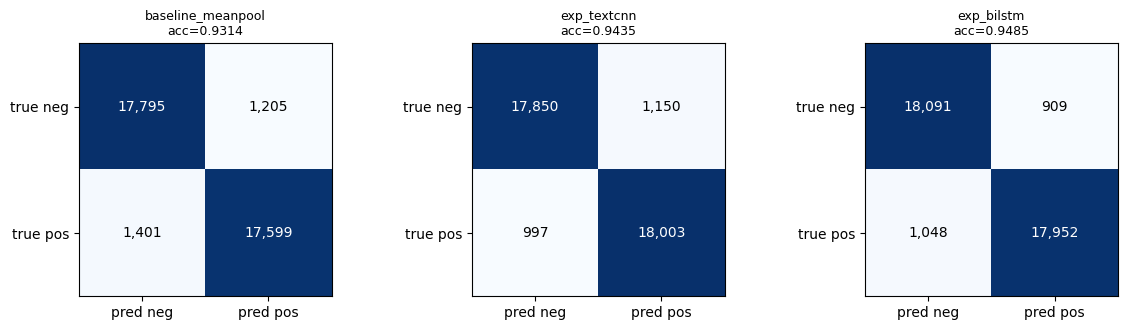

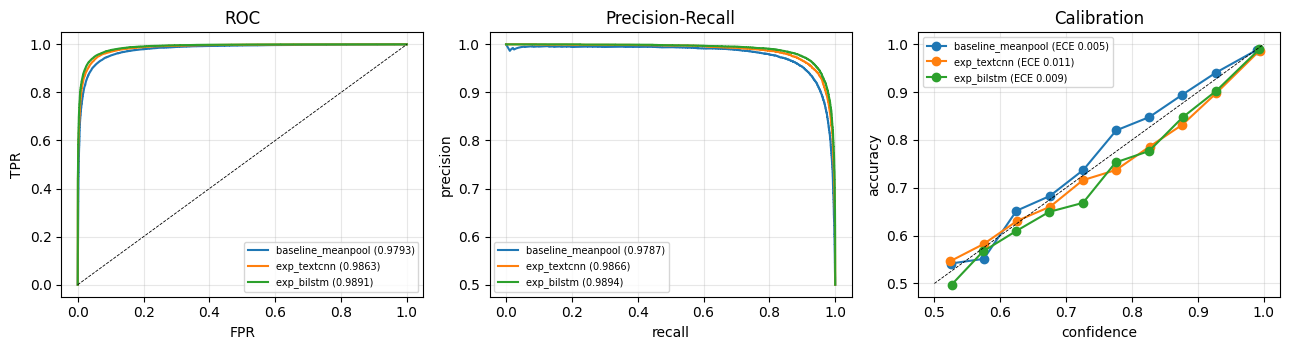

In [10]:
fig, axes = plt.subplots(1, len(names), figsize=(4 * len(names), 3.4))
for ax, n in zip(np.atleast_1d(axes), names):
    cm = confusion_matrix(yte, preds[n])
    ax.imshow(cm, cmap="Blues")
    for (i, j), v in np.ndenumerate(cm):
        ax.text(j, i, f"{v:,}", ha="center", va="center",
                color="white" if v > cm.max() / 2 else "black")
    ax.set_title(f"{n}\nacc={results[n]['accuracy']:.4f}", fontsize=9)
    ax.set_xticks([0, 1], ["pred neg", "pred pos"]); ax.set_yticks([0, 1], ["true neg", "true pos"])
fig.tight_layout(); fig.savefig(PLOTS / "confusion_matrices.png", dpi=120); plt.show()

fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
for n in names:
    fpr, tpr, _ = roc_curve(yte, probs[n])
    ax[0].plot(fpr, tpr, label=f"{n} ({results[n]['roc_auc']:.4f})")
    pr, rc, _ = precision_recall_curve(yte, probs[n])
    ax[1].plot(rc, pr, label=f"{n} ({results[n]['pr_auc']:.4f})")
    conf = np.maximum(probs[n], 1 - probs[n])
    correct = (preds[n] == yte).astype(float)
    xs, ys = [], []
    edges = np.linspace(0.5, 1.0, 11)
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (conf > lo) & (conf <= hi)
        if m.sum() > 20:
            xs.append(conf[m].mean()); ys.append(correct[m].mean())
    ax[2].plot(xs, ys, "o-", label=f"{n} (ECE {results[n]['ece']:.3f})")

ax[0].plot([0, 1], [0, 1], "k--", lw=.6)
ax[0].set_title("ROC"); ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR")
ax[1].set_title("Precision-Recall"); ax[1].set_xlabel("recall"); ax[1].set_ylabel("precision")
ax[2].plot([.5, 1], [.5, 1], "k--", lw=.6)
ax[2].set_title("Calibration"); ax[2].set_xlabel("confidence"); ax[2].set_ylabel("accuracy")
for a in ax:
    a.legend(fontsize=7); a.grid(alpha=.3)
fig.tight_layout(); fig.savefig(PLOTS / "curves.png", dpi=120); plt.show()


## McNemar vs baseline, and per-slice robustness


In [11]:
BASE = "baseline_meanpool"
mc_rows = []
for n in names:
    if n == BASE:
        continue
    r = dict(mcnemar(yte, preds[BASE], preds[n]), comparison=f"{BASE} vs {n}")
    mc_rows.append(r)
    log(f"McNemar {BASE} vs {n}: base-only {r['a_only']} exp-only {r['b_only']} "
        f"p={r['p_value']:.3g} ({r['test']})")
mcnemar_df = pd.DataFrame(mc_rows)
mcnemar_df.to_csv(OUT / "mcnemar.csv", index=False)

test_len = np.array([len(t) for t in test_tok])
has_neg = np.array([any(w in NEGATIONS for w in t) for t in test_tok])
slices = {
    "len<=40": test_len <= 40,
    "len41-100": (test_len > 40) & (test_len <= 100),
    "len>100": test_len > 100,
    "has_negation": has_neg,
    "no_negation": ~has_neg,
}

rows = []
for n in names:
    for sname, m in slices.items():
        if m.sum() < 50:
            continue
        rows.append({"model": n, "slice": sname, "n": int(m.sum()),
                     "macro_f1": macro_f1(yte[m], preds[n][m]),
                     "error_rate": float((preds[n][m] != yte[m]).mean())})
slice_df = pd.DataFrame(rows)
slice_df.to_csv(OUT / "slice_metrics.csv", index=False)
slice_df.pivot(index="slice", columns="model", values="macro_f1").round(4)


22:32:55 | McNemar baseline_meanpool vs exp_textcnn: base-only 775 exp-only 1234 p=1.64e-24 (chi2 corrected)
22:32:55 | McNemar baseline_meanpool vs exp_bilstm: base-only 540 exp-only 1189 p=9.36e-55 (chi2 corrected)


model,baseline_meanpool,exp_bilstm,exp_textcnn
slice,,,
has_negation,0.9237,0.9451,0.9397
len41-100,0.9317,0.9491,0.9455
len<=40,0.9312,0.9489,0.9433
len>100,0.9236,0.9405,0.9336
no_negation,0.9271,0.9363,0.9300


## 2.2.4 Error review

20 errors from the best model: 5 confident false positives, 5 confident false negatives,
5 near-threshold, 5 from the negation slice. The buckets overlap, so rows already picked are
skipped. Assign the error type and the fix yourself in `failure_analysis.md`.


In [12]:
best = max(names, key=lambda n: results[n]["accuracy"])
prob, pred = probs[best], preds[best]
conf = np.maximum(prob, 1 - prob)
wrong = np.where(pred != yte)[0]
k = E["n_errors_per_bucket"]
log(f"errors from {best} (acc {results[best]['accuracy']:.4f}): {len(wrong):,} wrong")

fp = wrong[yte[wrong] == 0]
fn = wrong[yte[wrong] == 1]
neg = wrong[has_neg[wrong]]
candidates = {
    "confident_false_positive": fp[np.argsort(-conf[fp])],
    "confident_false_negative": fn[np.argsort(-conf[fn])],
    "near_threshold": wrong[np.argsort(np.abs(prob[wrong] - 0.5))],
    "slice_negation": neg[np.argsort(-conf[neg])],
}

buckets, used = {}, set()
for bname, ranked in candidates.items():
    picked = [int(i) for i in ranked if int(i) not in used][:k]
    used.update(picked)
    buckets[bname] = picked
    if len(picked) < k:
        log(f"  {bname}: only {len(picked)}/{k} available")

rows = [{"bucket": b, "row": i, "true": int(yte[i]), "pred": int(pred[i]),
         "p_positive": round(float(prob[i]), 4), "n_tokens": int(test_len[i]),
         "has_negation": bool(has_neg[i]), "text": test_df.text.iloc[i][:600]}
        for b, idxs in buckets.items() for i in idxs]
errors_df = pd.DataFrame(rows)
errors_df.to_csv(OUT / "error_review.csv", index=False)

with open(OUT / "error_review.md", "w") as f:
    f.write(f"# Error review - {best} ({RUN_TAG})\n")
    for b in buckets:
        f.write(f"\n## {b}\n")
        for _, r in errors_df[errors_df.bucket == b].iterrows():
            f.write(f"\n**row {r.row}** true={r.true} pred={r.pred} p(pos)={r.p_positive} "
                    f"tokens={r.n_tokens} negation={r.has_negation}\n\n> {r.text}\n\n"
                    f"- error type: \n- testable fix: \n")

log(f"{len(errors_df)} errors -> outputs/error_review.md")
errors_df[["bucket", "row", "true", "pred", "p_positive", "n_tokens", "has_negation"]]


22:32:55 | errors from exp_bilstm (acc 0.9485): 1,957 wrong
22:32:55 | 20 errors -> outputs/error_review.md


,bucket,row,true,pred,p_positive,n_tokens,has_negation
0,confident_false_positive,29330,0,1,0.9993,18,False
1,confident_false_positive,408,0,1,0.9993,57,True
2,confident_false_positive,5752,0,1,0.9990,220,True
3,confident_false_positive,14825,0,1,0.9986,132,True
4,confident_false_positive,5185,0,1,0.9983,39,True
5,confident_false_negative,22807,1,0,0.0001,46,True
6,confident_false_negative,30793,1,0,0.0001,38,True
7,confident_false_negative,22451,1,0,0.0008,111,True
8,confident_false_negative,20061,1,0,0.0011,278,True
9,confident_false_negative,16700,1,0,0.0011,45,True


## 2.3 Comparison table


In [13]:
rows = []
for n in names:
    r = runs[n]
    rec = {"model_id": f"{MEMBER}_{n}", "run_tag": RUN_TAG, "model": n,
           "type": CFG["models"][n]["type"], "role": "baseline" if n == BASE else "experimental",
           "params": r["params"], "train_time_s": round(r["train_time_s"], 1),
           "examples_per_sec": round(r["examples_per_sec"], 1),
           "peak_mem_mb": round(r["peak_mem_mb"], 1), "hardware": HW,
           "best_val_acc": round(r["best_val_acc"], 4)}
    rec.update({k: (round(v, 6) if isinstance(v, float) else v) for k, v in results[n].items()})
    mc = mcnemar_df[mcnemar_df.comparison == f"{BASE} vs {n}"]
    rec["mcnemar_p_vs_baseline"] = float(mc.p_value.iloc[0]) if len(mc) else ""
    for _, s in slice_df[slice_df.model == n].iterrows():
        rec[f"macro_f1__{s['slice']}"] = round(s.macro_f1, 4)
        rec[f"error_rate__{s['slice']}"] = round(s.error_rate, 4)
    rows.append(rec)

metrics_df = pd.DataFrame(rows).fillna("")
metrics_df.to_csv(MDIR / "metrics_report.csv", index=False)
log(f"metrics_report.csv: {len(metrics_df)} models x {len(metrics_df.columns)} columns")

metrics_df[["model", "type", "role", "params", "accuracy", "f1_macro", "roc_auc", "pr_auc",
            "mcc", "brier", "ece", "train_time_s", "examples_per_sec", "peak_mem_mb",
            "mcnemar_p_vs_baseline"]].round(4)


22:32:55 | metrics_report.csv: 3 models x 47 columns


,model,type,role,params,accuracy,f1_macro,roc_auc,pr_auc,mcc,brier,ece,train_time_s,examples_per_sec,peak_mem_mb,mcnemar_p_vs_baseline
0,baseline_meanpool,meanpool,baseline,9687602,0.9314,0.9314,0.9793,0.9787,0.8629,0.0516,0.0046,41.4,39501.9,338.4,
1,exp_textcnn,textcnn,experimental,9928102,0.9435,0.9435,0.9863,0.9866,0.8870,0.0430,0.0111,247.8,6546.9,460.3,0.0
2,exp_bilstm,bilstm,experimental,10025634,0.9485,0.9485,0.9891,0.9894,0.8970,0.0384,0.0086,349.5,4637.3,2285.9,0.0


## Manifest


In [14]:
def sha256(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for blk in iter(lambda: f.read(1 << 20), b""):
            h.update(blk)
    return h.hexdigest()

freeze = subprocess.run([sys.executable, "-m", "pip", "freeze"],
                        capture_output=True, text=True).stdout.splitlines()

manifest = {
    "run_tag": RUN_TAG,
    "task": "task2_sentiment",
    "member": MEMBER,
    "timestamp": datetime.now().isoformat(timespec="seconds"),
    "seed": SEED,
    "config": CFG,
    "hardware": {"device": str(DEVICE), "cpu_gpu": HW, "platform": platform.platform(),
                 "python": platform.python_version(), "torch": torch.__version__},
    "data": {"train": len(train_df), "val": len(val_df), "test": len(test_df),
             "vocab_size": VOCAB, "max_len": MAX_LEN, "unk_rate": unk_rate},
    "models": {n: {"params": runs[n]["params"],
                   "checkpoint": f"task2_sentiment/{MEMBER}/checkpoints/{n}.pt",
                   "sha256": sha256(CKPT / f"{n}.pt"),
                   "accuracy": results[n]["accuracy"],
                   "f1_macro": results[n]["f1_macro"]} for n in names},
    "raw_log": f"reproducibility/raw_logs/{MEMBER}/task2_sentiment/{RUN_TAG}.log",
    "metrics_report": f"task2_sentiment/{MEMBER}/metrics_report.csv",
    "pip_freeze": freeze,
}
(MANIFESTS / f"{RUN_TAG}.json").write_text(json.dumps(manifest, indent=2))
(MDIR / "requirements.txt").write_text("\n".join(freeze) + "\n")
log(f"manifest -> reproducibility/manifests/{RUN_TAG}.json")
print(json.dumps({n: manifest["models"][n]["accuracy"] for n in names}, indent=2))


22:32:57 | manifest -> reproducibility/manifests/task2_shreya_main_20260921_222011.json
{
  "baseline_meanpool": 0.9314210526315789,
  "exp_textcnn": 0.9435,
  "exp_bilstm": 0.9485
}


## Next

Write `failure_analysis.md` from `outputs/error_review.md`, and `results.md` for the architecture
and embedding justification plus the comparative analysis.
